# GridCAT Python

Beta version of the translation of the GridCAT toolbox (Stangl et al., 2017) from Matlab to Python.

Example Notebook documenting Workflow.

Rerun requires the ExampleData.zip from  https://www.nitrc.org/projects/gridcat 

Tested on Python 3.9.21. See `requirements.txt` for the required libraries.

### Preparations

In [26]:
import os
import glob
import pandas as pd
from scipy.linalg import block_diag

import matplotlib.pyplot as plt
import nibabel as nib
from nilearn.image import concat_imgs
from nilearn.plotting import plot_design_matrix

# Custom modules
import Compare
from gridcat import gridcat, event_use


Set base_path to the root directory of the ExampleData folder.

In [ ]:
# Option 1: use the current working directory if the notebook is in ExampleData.
# base_path = os.getcwd()

# Option 2: update this to your local ExampleData directory.
base_path = "/path/to/your/ExampleData/"  # <-- CHANGE THIS before running

Set the analysis parameters and event-splitting strategy.

In [ ]:
# Analysis parameters
# Set to Paramters of Example Data
tr = 1.5
xFold = 6
keep_unused_events = False
high_pass_period = 128
smoothing_fwhm = None
slice_time_ref = 0.5  # Matches the Matlab slice timing convention used for this dataset.

# Options: half_first, half_second, odd_first, even_first, all, table
event_usage_specifier, glm2_event_usage_specifier = event_use("half_first")

keep_unused_events_glm2 = False
glm2_use_weighting = True   # Weight mean orientation calculation by amplitude
glm2_average_runs = False   # Average mean orientation across runs
glm2_method = "pmod"         # 'pmod' or 'aligned_misaligned'

# Threshold for SPM-style mask creation
masking_threshold = 0.95

trial_type = "translation"


Create output folders and define data paths.

In [6]:
# Output directories
glm1_output_dir = os.path.join(base_path, "glm1_output_py")
os.makedirs(glm1_output_dir, exist_ok=True)

glm2_output_dir = os.path.join(base_path, "glm2_output_py")
os.makedirs(glm2_output_dir, exist_ok=True)

grid_ori_output_dir = os.path.join(glm1_output_dir, "GridOrientation")
os.makedirs(grid_ori_output_dir, exist_ok=True)

# Input data paths
scanFolder_run1 = os.path.join(base_path, "FunctionalScans", "run1")
scanFolder_run2 = os.path.join(base_path, "FunctionalScans", "run2")

event_table_1 = os.path.join(base_path, "EventTables", "eventTable_run1.txt")
event_table_2 = os.path.join(base_path, "EventTables", "eventTable_run2.txt")

regressor_file_1 = os.path.join(base_path, "AdditionalRegressors", "realignmentParameters_run1.txt")
regressor_file_2 = os.path.join(base_path, "AdditionalRegressors", "realignmentParameters_run2.txt")

run_folders    = {1: scanFolder_run1, 2: scanFolder_run2}
event_tables   = {1: event_table_1,   2: event_table_2}
regressor_files = {1: regressor_file_1, 2: regressor_file_2}
run_indices    = sorted(run_folders.keys())  # [1, 2]

# Sanity check: confirm all runs have the same number of scans
n_scans_per_run = {}
for run_idx in run_indices:
    scan_files = (glob.glob(os.path.join(run_folders[run_idx], "*.nii")) +
                  glob.glob(os.path.join(run_folders[run_idx], "*.nii.gz")))
    n_scans_per_run[run_idx] = len(scan_files)

if len(set(n_scans_per_run.values())) == 1:
    print(f"Number of scans is consistent across runs: {list(n_scans_per_run.values())[0]} per run.")
else:
    print(f"Warning: Different number of scans found per run: {n_scans_per_run}")

# ROI masks used for metric calculation
roi_mask_paths = [
    os.path.join(base_path, "ROI_masks", "ROImask_entorhinalCortex_RH.nii"),
    os.path.join(base_path, "ROI_masks", "ROImask_entorhinalCortex_LH.nii")
]

matlab_base_path = os.path.join(base_path, "Matlab_GridCat_Output")
matlab_glm1_dir = os.path.join(matlab_base_path, "GLM1")
matlab_glm2_dir = os.path.join(matlab_base_path, "GLM2")

metrics_output_file = os.path.join(glm2_output_dir, "GridCAT_python_grid_metrics.tsv")


Number of scans is consistent across runs: 640 per run.


Create an SPM-style mask so the Python and Matlab GLMs use comparable voxels.

In [7]:
# Initialize gridcat object
gc = gridcat(base_path)

# Initialize comparator (used throughout for Python vs Matlab comparisons)
comparator = Compare.Comp()

all_run_folders = [scanFolder_run1, scanFolder_run2]
spm_masking_threshold = masking_threshold
mask_filename = "python_gridcat_mask_py.nii.gz"

# create_spm_mask returns a Nifti1Image used by both GLMs.
python_mask = gc.create_spm_mask(
    run_folders=all_run_folders,
    masking_threshold_fraction=spm_masking_threshold,
    mask_filename=mask_filename,
    matlab_compare=False
)


Reference image shape set to: (108, 108, 24)
Calculated mean image from 1280 processed 3D files.
Global mean intensity of the mean image: 184.4280
Intensity threshold for mask: 175.2066
Mask includes 79496 voxels.


### GLM 1

Run GLM1 for each functional run.

Running GLM1 for Run 1
Read 155 events from eventTable_run1.txt
Read 640 timepoints for 6 additional regressors from realignmentParameters_run1.txt
Found 640 functional scans for run 1.
Found 111 'translation' events with orientation.
Applying selection rule: 2
  Rule 2: Selecting first half - 56 of 111 grid events.
Fitting FirstLevelModel for run 1
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] Computing run 1 out of 1 runs (go take a coffee, a big one).
[FirstLevelModel.fit] Performing mask computation.
[FirstLevelModel.fit] Masking took 1 seconds.
[FirstLevelModel.fit] Performing GLM computation.
[FirstLevelModel.fit] GLM took 49 seconds.
[FirstLevelModel.fit] Computation of 1 runs done in 51 seconds.


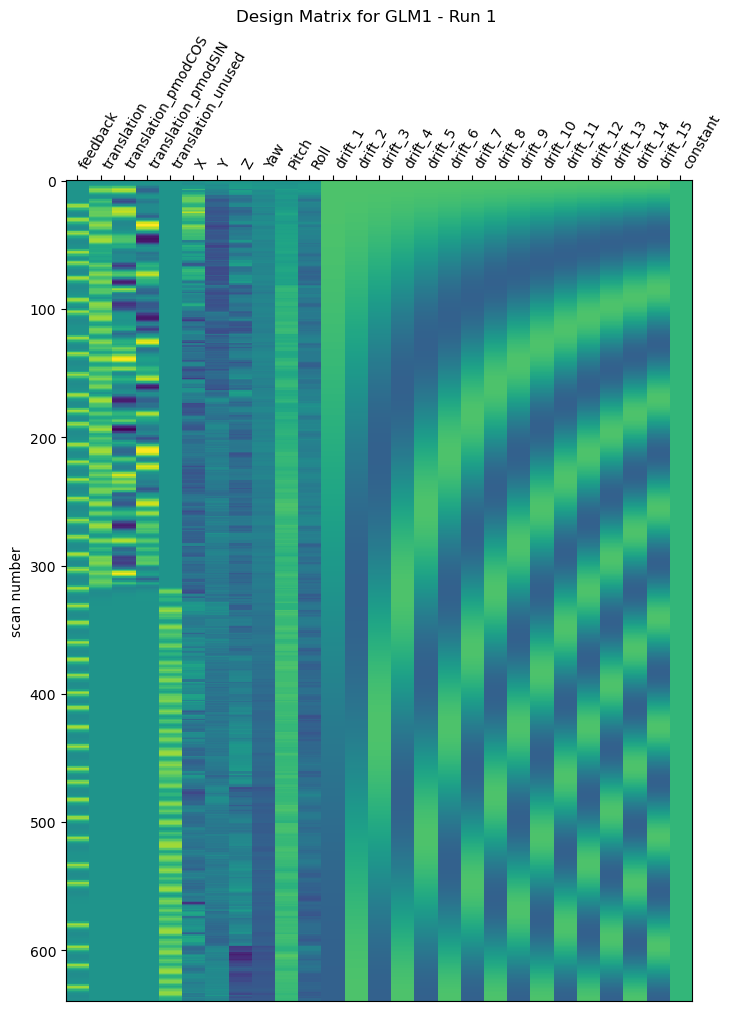

GLM1 Fitting complete for run 1.
Running GLM1 for Run 2
Read 150 events from eventTable_run2.txt
Read 640 timepoints for 6 additional regressors from realignmentParameters_run2.txt
Found 640 functional scans for run 2.
Found 109 'translation' events with orientation.
Applying selection rule: 2
  Rule 2: Selecting first half - 55 of 109 grid events.
Fitting FirstLevelModel for run 2
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] Computing run 1 out of 1 runs (go take a coffee, a big one).
[FirstLevelModel.fit] Performing mask computation.
[FirstLevelModel.fit] Masking took 1 seconds.
[FirstLevelModel.fit] Performing GLM computation.
[FirstLevelModel.fit] GLM took 51 seconds.
[FirstLevelModel.fit] Computation of 1 runs done in 53 seconds.


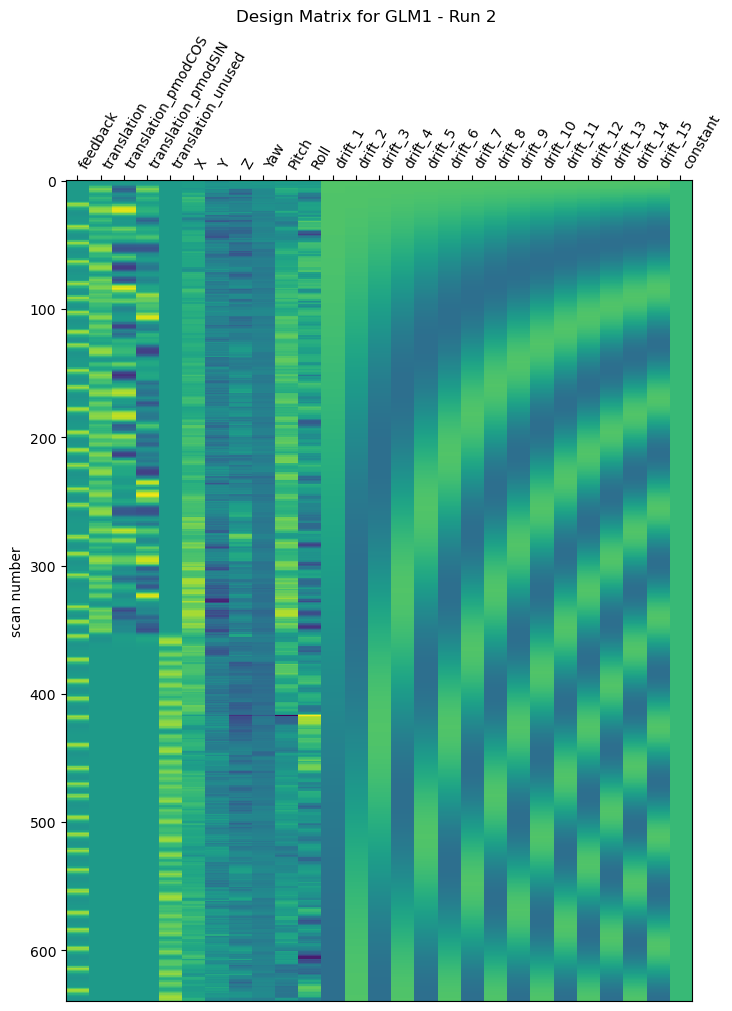

GLM1 Fitting complete for run 2.
GLM1 successfully completed for runs: [1, 2]


In [ ]:
# Run GLM1 for each run.
glm1_models = {}

for run_idx in run_indices:
    _events_nilearn, model = gc.run_glm1_single_run(
        event_table_file=event_tables[run_idx],
        regressor_file=regressor_files[run_idx],
        scanFolder_run=run_folders[run_idx],
        run_number=run_idx,
        event_usage_specifier=event_usage_specifier,
        xFold=xFold,
        tr=tr,
        high_pass_period=high_pass_period,
        smoothing_fwhm=smoothing_fwhm,
        slice_time_ref=slice_time_ref,
        mask=python_mask
    )

    glm1_models[run_idx] = model

# Track the runs where GLM1 completed successfully.
run_indices_glm1_success = sorted(glm1_models)
print(f"GLM1 successfully completed for runs: {run_indices_glm1_success}")


Compute voxelwise grid orientations and amplitudes.

In [ ]:
# Calculate and save results for each successful run using gridcat class
gc.calculate_betas(run_indices_glm1_success, glm1_models, xFold, grid_ori_output_dir)

Calculating orientation/amplitude for GLM1 run 1
  Saved orientation and amplitude maps for run 1.
Calculating orientation/amplitude for GLM1 run 2
  Saved orientation and amplitude maps for run 2.
Calculating Avergae orientation/amplitude for GLM1
Saved averaged orientation and amplitude maps.


**GLM1 Output files**

The following files are saved to `glm1_output_py/GridOrientation/`:

- `voxelwiseAmplitude_translation_run<N>.nii` - per-voxel amplitude for each run
- `voxelwiseAmplitude_translation_allRunsAvg.nii` - amplitude averaged across runs
- `voxelwiseGridOri_translation_run<N>_deg.nii` - per-voxel grid orientation in degrees for each run
- `voxelwiseGridOri_translation_allRunsAvg_deg.nii` - orientation averaged across runs

Additionally, `python_gridcat_mask_py.nii.gz` is saved to `base_path`.


### GLM 2

In [14]:
# Calculate the GLM2 reference orientation from the selected GLM1 ROI.
mean_ori_rad = gc.calculate_mean_grid_orientation(
    glm1_dir=glm1_output_dir,
    roi_mask_path=roi_mask_paths[0],
    xFold=xFold,
    use_weighting=glm2_use_weighting,
    average_across_runs=glm2_average_runs,
    run_indices=run_indices_glm1_success,
    grid_event_name="translation"
)

 Calculating Mean Grid Orientation (Per Run)
  GLM1 Dir: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/glm1_output_py/GridOrientation
  ROI Mask: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/ROI_masks/ROImask_entorhinalCortex_RH.nii
  Weighting: True, AverageRuns Flag: False
  Loaded ROI mask.
  Calculating mean orientation per run...
 Calculated ROI Mean Orientation (Avg 1): 32.456 deg
 Calculated ROI Mean Orientation (Avg 2): 32.014 deg


Set up GLM2 events.

Fit GLM2 once across all runs and once per run. The per-run models are needed for single-run contrasts, which are not available from the combined Nilearn model.

In [15]:
prepared_glm2_data = {}

print(f"Preparing Data for GLM2 using runs: {run_indices_glm1_success}")
for run_idx in run_indices_glm1_success:
    print(f"Processing Run {run_idx} for GLM2")
    try:
        base_event_df_run = gc.read_event_table_to_df(event_tables[run_idx])

        events_with_glm2_usage = gc.select_events_for_glm(
            base_event_df_run,
            usage_specifier=glm2_event_usage_specifier,
            output_column_name='use_in_GLM2'
        )

        glm2_events_nilearn_df = gc.prepare_glm2_events(
            base_event_df=events_with_glm2_usage,
            mean_ori_rad=mean_ori_rad[str(run_idx)],
            xFold=xFold,
            method=glm2_method,
            keep_unused_events=keep_unused_events_glm2,
            run=run_idx
        )

        add_reg_df_run = gc.read_additional_regressors_to_df(regressor_files[run_idx])

        func_files = sorted(
            glob.glob(os.path.join(run_folders[run_idx], "*.nii")) +
            glob.glob(os.path.join(run_folders[run_idx], "*.nii.gz"))
        )
        if not func_files:
            print(f"  WARNING: No functional files found for run {run_idx}. Skipping.")
            continue

        run_4d_img = concat_imgs(func_files, auto_resample=True)
        print(f"  Loaded {len(func_files)} scans for GLM2 run {run_idx}, shape: {run_4d_img.shape}")

        prepared_glm2_data[run_idx] = {
            'img': run_4d_img,
            'events': glm2_events_nilearn_df,
            'confounds': add_reg_df_run
        }
    except Exception as e:
        print(f"  ERROR: Failed to process run {run_idx} for GLM2. Reason: {e}")

runs_for_glm2 = sorted(prepared_glm2_data.keys())
print(f"Successfully prepared data for runs: {runs_for_glm2}")

if runs_for_glm2:
    glm2_run_img_objects = [prepared_glm2_data[r]['img']       for r in runs_for_glm2]
    glm2_events_list     = [prepared_glm2_data[r]['events']    for r in runs_for_glm2]
    glm2_confounds_list  = [prepared_glm2_data[r]['confounds'] for r in runs_for_glm2]

    glm2_model = gc.setup_first_level_model(tr, high_pass_period, smoothing_fwhm, slice_time_ref, python_mask)
    glm2_model.fit(glm2_run_img_objects, events=glm2_events_list, confounds=glm2_confounds_list)
    print("GLM2 Model Fitting Complete (All Runs)")
else:
    print("No data available to fit the multi-run GLM2 model.")

# Per-run models (needed for single-run contrasts)
for run_to_fit in [1, 2]:
    if run_to_fit in prepared_glm2_data:
        print(f"\n--- Fitting GLM2 for Run {run_to_fit} Only ---")
        model_single = gc.setup_first_level_model(tr, high_pass_period, smoothing_fwhm, slice_time_ref, python_mask)
        model_single.fit(
            [prepared_glm2_data[run_to_fit]['img']],
            events=[prepared_glm2_data[run_to_fit]['events']],
            confounds=[prepared_glm2_data[run_to_fit]['confounds']]
        )
        if run_to_fit == 1:
            glm2_model_run1 = model_single
        else:
            glm2_model_run2 = model_single
        print(f"GLM2 Model Fitting Complete (Run {run_to_fit} Only)")
    else:
        print(f"Data for Run {run_to_fit} not available.")


Preparing Data for GLM2 using runs: [1, 2]
Processing Run 1 for GLM2
Read 155 events from eventTable_run1.txt
Found 111 'translation' events with orientation.
Applying selection rule: 3
  Rule 3: Selecting second half - 55 of 111 grid events.
Preparing Events for GLM2 using method: pmod
prepare_glm2_events generated 154 event entries for Nilearn.
Read 640 timepoints for 6 additional regressors from realignmentParameters_run1.txt
  Loaded 640 scans for GLM2 run 1, shape: (108, 108, 24, 640)
Processing Run 2 for GLM2
Read 150 events from eventTable_run2.txt
Found 109 'translation' events with orientation.
Applying selection rule: 3
  Rule 3: Selecting second half - 54 of 109 grid events.
Preparing Events for GLM2 using method: pmod
prepare_glm2_events generated 149 event entries for Nilearn.
Read 640 timepoints for 6 additional regressors from realignmentParameters_run2.txt
  Loaded 640 scans for GLM2 run 2, shape: (108, 108, 24, 640)
Successfully prepared data for runs: [1, 2]
[FirstLev

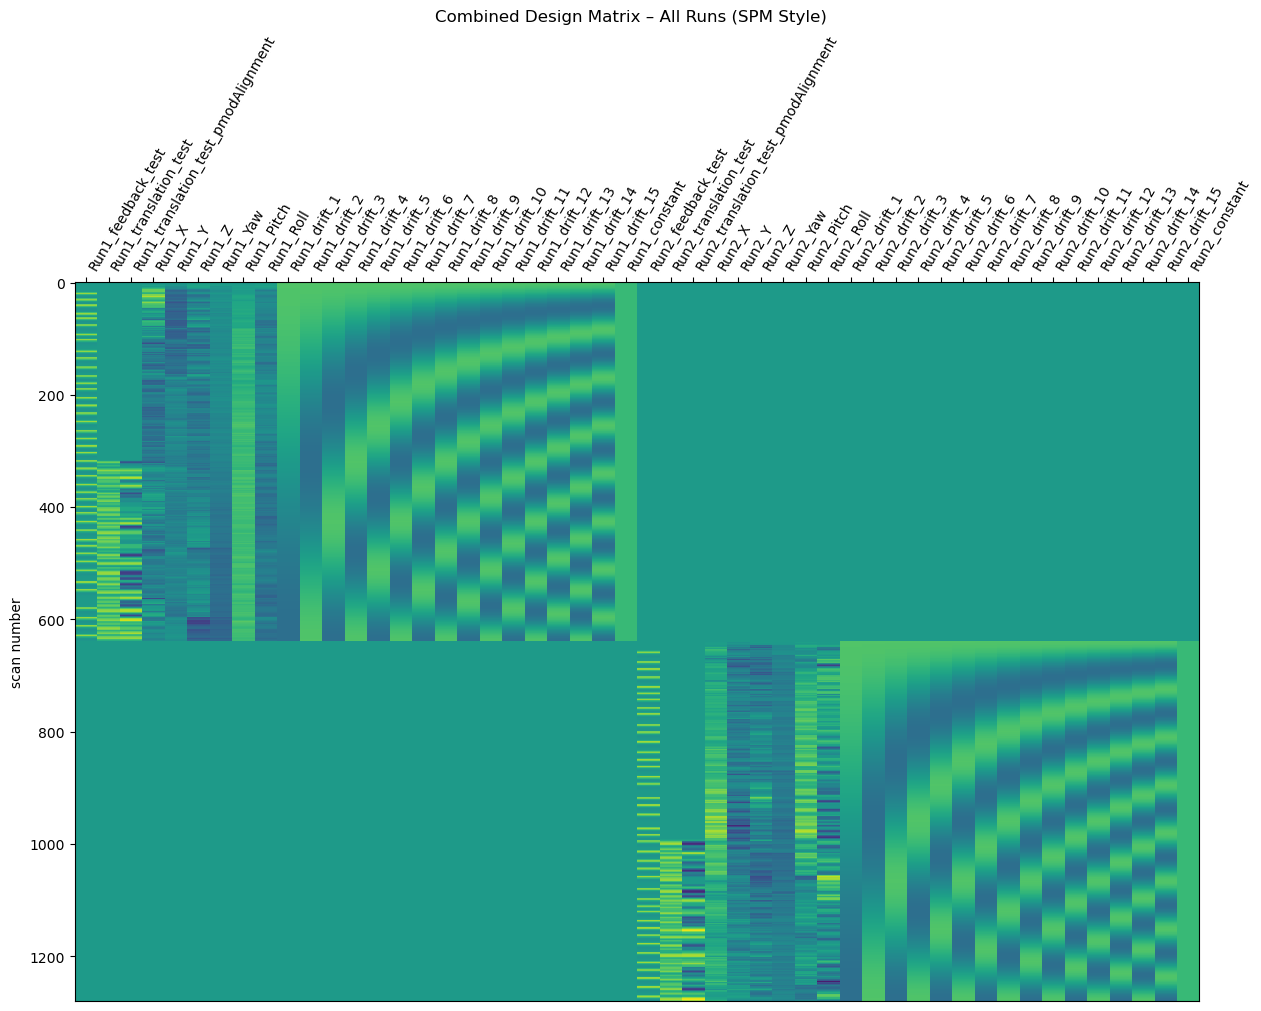

In [ ]:
# Build an SPM-style block-diagonal view of the run-wise design matrices to mask the original Matlab output.
dm_matrices = [dm.values for dm in glm2_model.design_matrices_]
dm_block = block_diag(*dm_matrices)

# Prefix column names with run number to avoid duplicates.
dm_colnames = []
for run_idx, dm in enumerate(glm2_model.design_matrices_):
    cols = [f"Run{run_idx+1}_{c}" for c in dm.columns]
    dm_colnames.extend(cols)

combined_block_df = pd.DataFrame(dm_block, columns=dm_colnames)

plot_design_matrix(combined_block_df)
plt.suptitle("Combined Design Matrix - All Runs (SPM Style)")
plt.show()

In [21]:
glm2_contrasts = gc.compute_glm2_contrasts(
    glm2_model_run1,
    glm2_model_run2,
    glm2_model,
    glm2_method,
    trial_type
)

Computing GLM2 Contrasts...


/Users/jannis/Desktop/gridcat_writeup/gridcat.py:747: UserWarning: One contrast given, assuming it for all 2 runs
  f"{method}_RunAverage": model_a.compute_contrast(contrast_definitions, output_type='effect_size', stat_type="t"),


Successfully computed 3 GLM2 contrasts.


Calculating and Exporting Final Metrics
Calculating and Exporting Grid Metrics to: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/glm2_output_py/GridCAT_python_grid_metrics.tsv
  Using GLM1 orientation/amplitude files from: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/glm1_output_py/GridOrientation
  Inferred run indices: [1, 2]

Metric 1: Grid Code Response Magnitude (GLM2)

Metric 2: Between-Voxel Coherence (GLM1)

Metric 3: Within-Voxel Coherence (GLM1)

Metric 4: Mean Grid Orientation (calculated from GLM1)
 Calculating Mean Grid Orientation (Per Run)
  GLM1 Dir: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/glm1_output_py/GridOrientation
  ROI Mask: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/ROI_masks/ROImask_entorhinalCortex_RH.nii
  Weighting: True, AverageRuns Flag: False
  Loaded ROI mask.
  Calculating mean orientation per run...
 Calculated ROI Mean Orientation (Avg 1): 32.456 deg
 Calculated ROI Mean Orientation (Avg 2): 32.014 deg
 Calculating Me

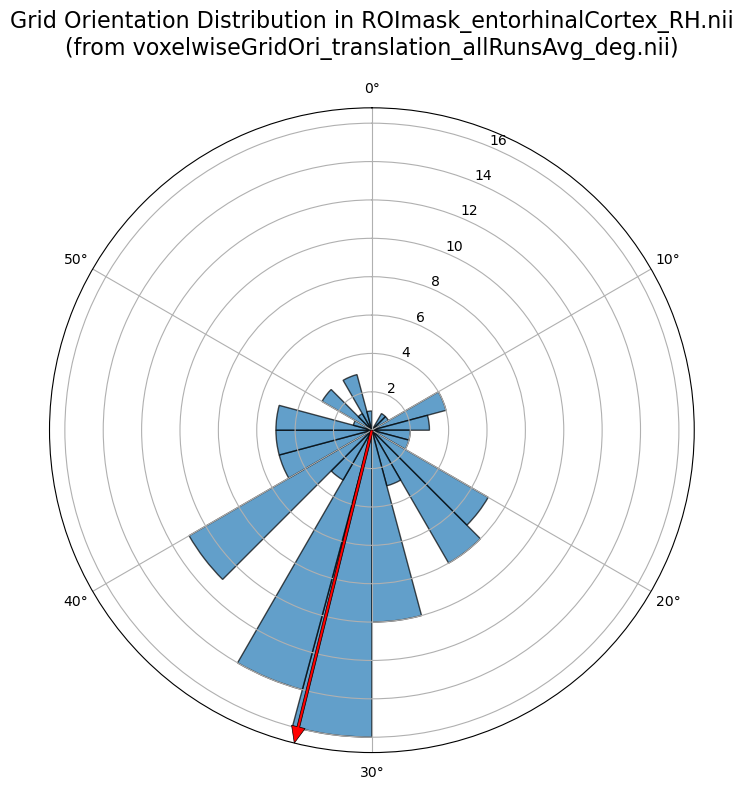

 Calculating Mean Grid Orientation (Per Run)
  GLM1 Dir: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/glm1_output_py/GridOrientation
  ROI Mask: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/ROI_masks/ROImask_entorhinalCortex_RH.nii
  Weighting: True, AverageRuns Flag: False
  Loaded ROI mask.
  Calculating mean orientation per run...
 Calculated ROI Mean Orientation (Avg 1): 32.456 deg
 Calculated ROI Mean Orientation (Avg 2): 32.014 deg
 Calculating Mean Grid Orientation (Per Run)
  GLM1 Dir: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/glm1_output_py/GridOrientation
  ROI Mask: /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/ROI_masks/ROImask_entorhinalCortex_RH.nii
  Weighting: False, AverageRuns Flag: False
  Loaded ROI mask.
  Calculating mean orientation per run...
average Ori
 Calculated ROI Mean Orientation (Avg 1): 32.280 deg
average Ori
 Calculated ROI Mean Orientation (Avg 2): 32.173 deg
 Calculating Mean Grid Orientation (Avg Across Runs)
  GLM1 Dir

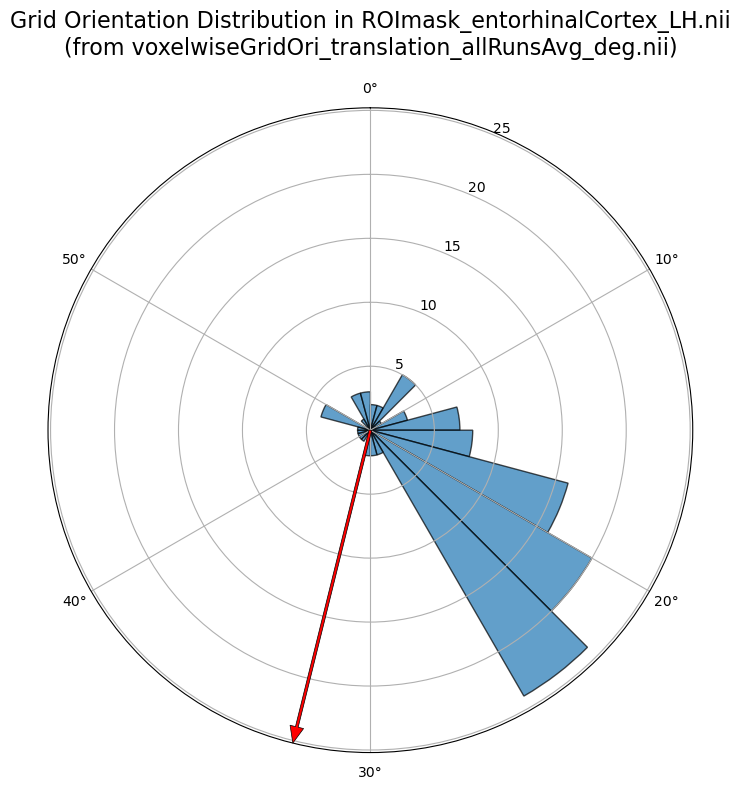

Successfully wrote metrics to /Users/jannis/Desktop/Praktikum/GridCAT/ExampleData/glm2_output_py/GridCAT_python_grid_metrics.tsv


In [ ]:
print("Calculating and Exporting Final Metrics")
all_metrics, python_contrasts = gc.calculate_and_export_metrics(
    roi_mask_paths=roi_mask_paths,
    glm1_dir=glm1_output_dir,
    glm2_contrasts=glm2_contrasts,
    output_file=metrics_output_file,
    xFold=xFold,
    grid_event_name="translation"
)

**GLM2 Output files**

The following files are saved to `glm2_output_py/`:

- `GridCAT_python_grid_metrics.tsv` - semicolon-separated metrics file with four sections:
  1. **Magnitude of grid code response within ROI** - mean GLM2 contrast value per ROI
  2. **Between-voxel orientation coherence** - Rayleigh test (z, p) on voxelwise orientations
  3. **Within-voxel orientation coherence** - percent of voxels with stable orientation across runs
  4. **Mean grid orientation within ROI** - weighted and unweighted circular mean per run
